# Import

In [20]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE

#  1. Load Data


In [21]:
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test  shape:", test_df.shape)
print(train_df.head())

Train shape: (440833, 12)
Test  shape: (64374, 12)
   CustomerID   Age  Gender  Tenure  Usage Frequency  Support Calls  \
0         2.0  30.0  Female    39.0             14.0            5.0   
1         3.0  65.0  Female    49.0              1.0           10.0   
2         4.0  55.0  Female    14.0              4.0            6.0   
3         5.0  58.0    Male    38.0             21.0            7.0   
4         6.0  23.0    Male    32.0             20.0            5.0   

   Payment Delay Subscription Type Contract Length  Total Spend  \
0           18.0          Standard          Annual        932.0   
1            8.0             Basic         Monthly        557.0   
2           18.0             Basic       Quarterly        185.0   
3            7.0          Standard         Monthly        396.0   
4            8.0             Basic         Monthly        617.0   

   Last Interaction  Churn  
0              17.0    1.0  
1               6.0    1.0  
2               3.0    1.0  
3  

In [22]:
# ── 2. Missing Values ─────────────────────────────────────────────────────────
print("\nMissing values:\n", train_df.isnull().sum())

imputer = SimpleImputer(strategy="median")
num_cols = ["Age"]
train_df[num_cols] = imputer.fit_transform(train_df[num_cols])
test_df[num_cols]  = imputer.transform(test_df[num_cols])

print("After imputation:", train_df.isnull().sum().sum(), "missing")


Missing values:
 CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64
After imputation: 11 missing


In [23]:
# ── 3. Encoding ───────────────────────────────────────────────────────────────
le = LabelEncoder()
for col in ["Gender", "Subscription Type", "Contract Length"]:
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col]  = le.transform(test_df[col].astype(str))

# 4. EDA 


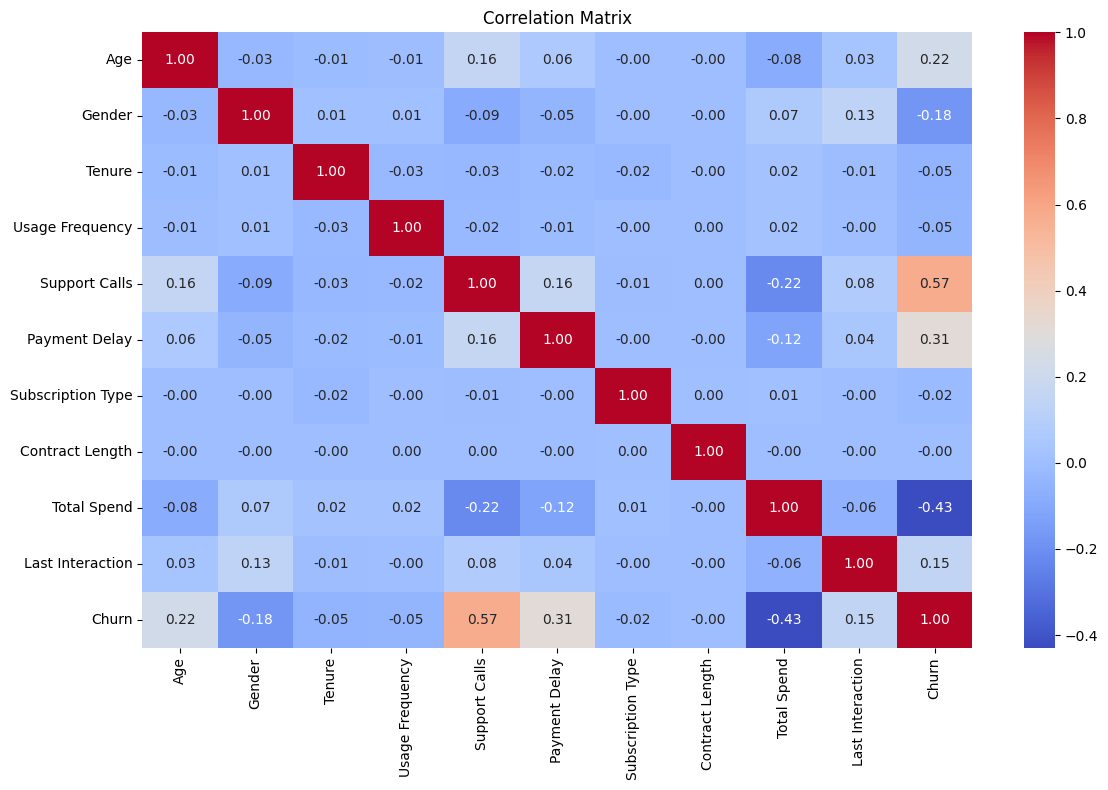

In [24]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_df.drop(columns=["CustomerID"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

#  5. Feature Selection 


In [25]:
drop_cols = ["CustomerID", "Tenure", "Usage Frequency", "Subscription Type", "Contract Length"]
train_df = train_df.dropna(subset=["Churn"])
X_train = train_df.drop(columns=drop_cols + ["Churn"])
y_train = train_df["Churn"]
X_test  = test_df.drop(columns=drop_cols + ["Churn"])
y_test  = test_df["Churn"]

print("Features:", list(X_train.columns))

Features: ['Age', 'Gender', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']


In [26]:
# ── 6. Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [27]:
# ── 7. SMOTE ──────────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_res).value_counts().to_dict())

Before SMOTE: {1.0: 249999, 0.0: 190833}
After  SMOTE: {1.0: 249999, 0.0: 249999}


#  8. Train Multiple Models 


In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
    "LightGBM":            LGBMClassifier(random_state=42, verbose=-1),
}

results = {}
for name, model in models.items():
    model.fit(X_res, y_res)
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results[name] = {
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "F1":       round(f1_score(y_test, preds), 4),
        "AUC-ROC":  round(roc_auc_score(y_test, proba), 4),
    }
    print(f"{name}: Acc={results[name]['Accuracy']} | F1={results[name]['F1']} | AUC={results[name]['AUC-ROC']}")

Logistic Regression: Acc=0.6012 | F1=0.6986 | AUC=0.7768
Decision Tree: Acc=0.5185 | F1=0.6626 | AUC=0.5425
Random Forest: Acc=0.5215 | F1=0.664 | AUC=0.5546
XGBoost: Acc=0.5217 | F1=0.6641 | AUC=0.709
LightGBM: Acc=0.5215 | F1=0.664 | AUC=0.6783


In [29]:
# 9. Comparison Table 
results_df = pd.DataFrame(results).T
print("\n=== Model Comparison ===")
print(results_df.sort_values("AUC-ROC", ascending=False))


=== Model Comparison ===
                     Accuracy      F1  AUC-ROC
Logistic Regression    0.6012  0.6986   0.7768
XGBoost                0.5217  0.6641   0.7090
LightGBM               0.5215  0.6640   0.6783
Random Forest          0.5215  0.6640   0.5546
Decision Tree          0.5185  0.6626   0.5425


In [30]:
# 10. Hyperparameter Tuning (XGBoost) 
param_grid = {
    "n_estimators":  [100, 200],
    "max_depth":     [4, 6],
    "learning_rate": [0.05, 0.1],
}

gs = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
    param_grid, cv=5, scoring="roc_auc", n_jobs=-1
)
gs.fit(X_res, y_res)

print("Best Params:", gs.best_params_)
print("Best CV AUC:", round(gs.best_score_, 4))

Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best CV AUC: 0.9868


#  11. Final Evaluation 


In [31]:
best_model = gs.best_estimator_
y_probs = best_model.predict_proba(X_test_scaled)[:, 1]
threshold = best_t   
best_preds = (y_probs > threshold).astype(int)
print("\n=== Final Classification Report ===")
print(classification_report(y_test, best_preds, target_names=["No Churn", "Churn"]))


=== Final Classification Report ===
              precision    recall  f1-score   support

    No Churn       0.98      0.09      0.17     33881
       Churn       0.50      1.00      0.66     30493

    accuracy                           0.52     64374
   macro avg       0.74      0.55      0.42     64374
weighted avg       0.75      0.52      0.40     64374



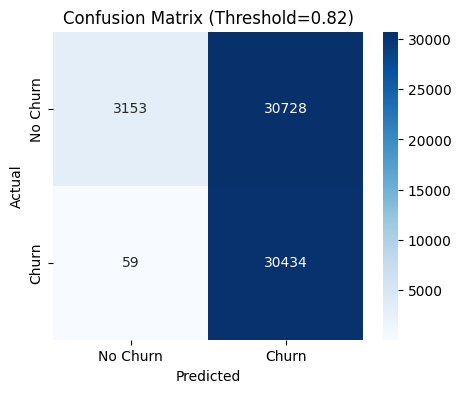

In [32]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"])

plt.title(f"Confusion Matrix (Threshold={threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

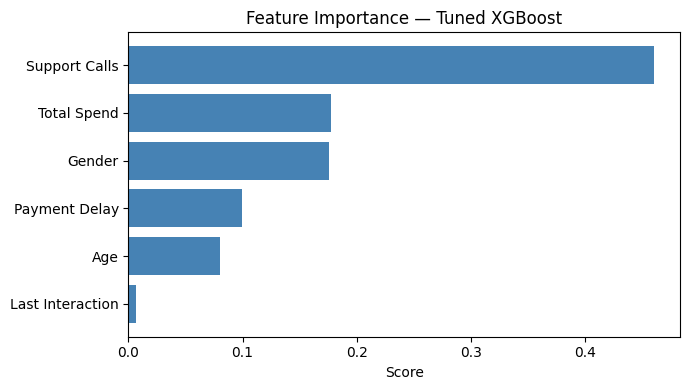

In [33]:
# ── 13. Feature Importance ────────────────────────────────────────────────────
feat_names   = list(X_train.columns)
importances  = best_model.feature_importances_
sorted_idx   = importances.argsort()

plt.figure(figsize=(7, 4))
plt.barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color="steelblue")
plt.title("Feature Importance — Tuned XGBoost")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

 Resplitting

In [46]:
from sklearn.model_selection import train_test_split

safe_features = [
    "Age",
    "Support Calls",
    "Total Spend",
    "Usage Frequency",
    "Tenure",
    "Gender"
]

X = train_df[safe_features]
y = train_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # مهم عشان balance
)

In [47]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_res, y_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After  SMOTE:", pd.Series(y_res).value_counts().to_dict())

Before SMOTE: {1.0: 199999, 0.0: 152666}
After  SMOTE: {0.0: 199999, 1.0: 199999}


In [51]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_res, y_res)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [52]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test)

print("\n--- XGBoost Performance ---")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- XGBoost Performance ---
Accuracy: 0.9478

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94     38167
         1.0       1.00      0.91      0.95     50000

    accuracy                           0.95     88167
   macro avg       0.95      0.95      0.95     88167
weighted avg       0.95      0.95      0.95     88167



In [38]:
import pandas as pd

corr = train_df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)
print(corr)

Churn                1.000000
Support Calls        0.574267
Payment Delay        0.312129
Age                  0.218394
Last Interaction     0.149616
Contract Length     -0.000093
Subscription Type   -0.017181
Usage Frequency     -0.046101
Tenure              -0.051919
Gender              -0.175395
Total Spend         -0.429355
CustomerID          -0.839365
Name: Churn, dtype: float64


In [53]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)
print(dt.score(X_test, y_test))

0.9175201606043077


In [50]:
print(train_df[safe_features].corrwith(train_df["Churn"]))

Age                0.218394
Support Calls      0.574267
Total Spend       -0.429355
Usage Frequency   -0.046101
Tenure            -0.051919
Gender            -0.175395
dtype: float64
